<a href="https://colab.research.google.com/github/kestrel677/UNSUPERVISED-MACHINE-LEARNING/blob/main/hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


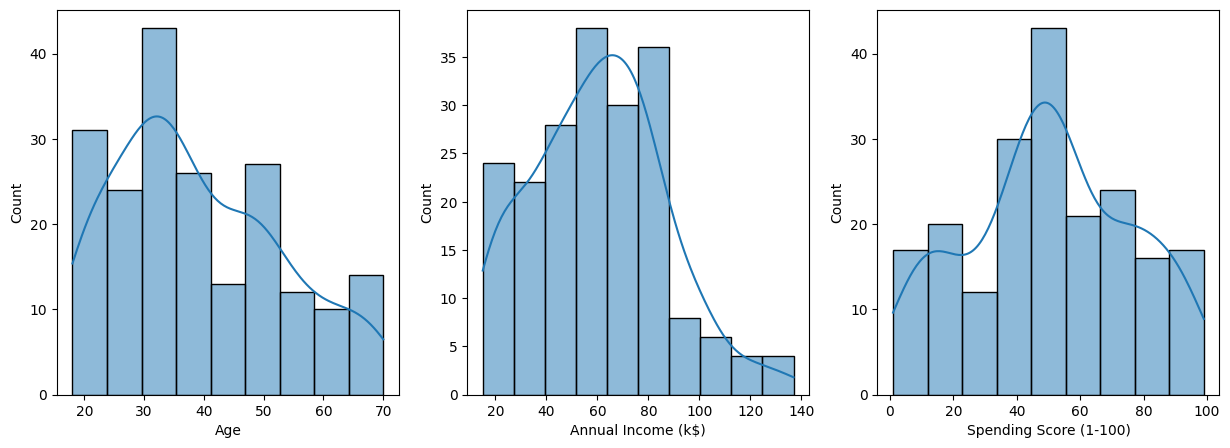

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['Age'], kde=True)

plt.subplot(1,3,2)
sns.histplot(df['Annual Income (k$)'], kde=True)

plt.subplot(1,3,3)
sns.histplot(df['Spending Score (1-100)'], kde=True)

plt.show()

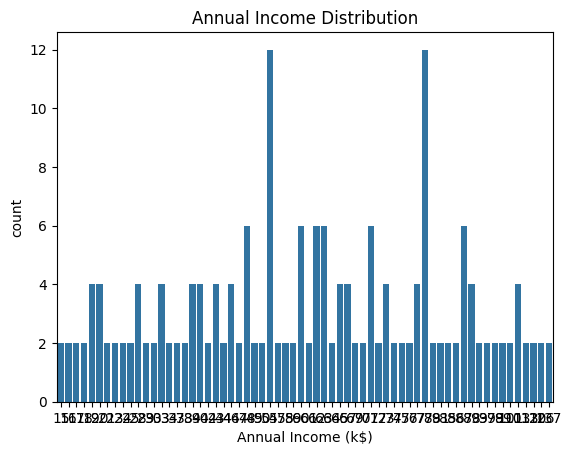

In [ ]:
sns.countplot(x='Annual Income (k$)', data=df)

plt.title("Annual Income Distribution")

plt.show()

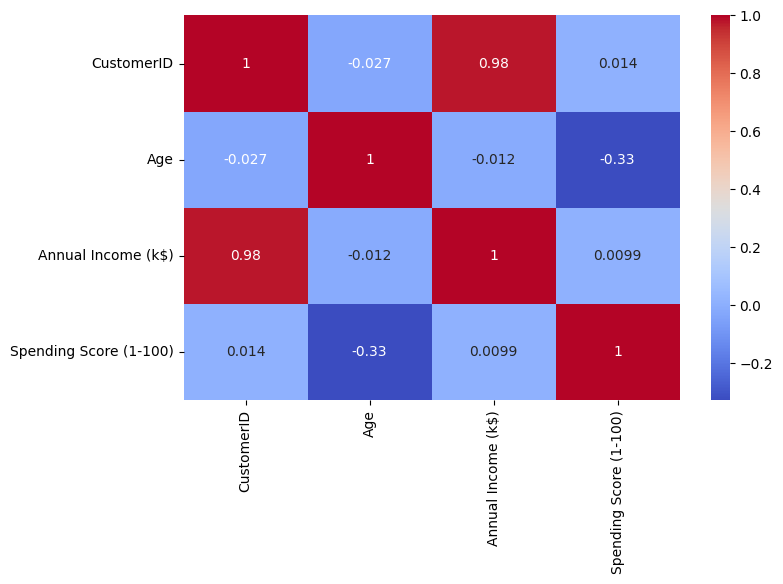

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.show()

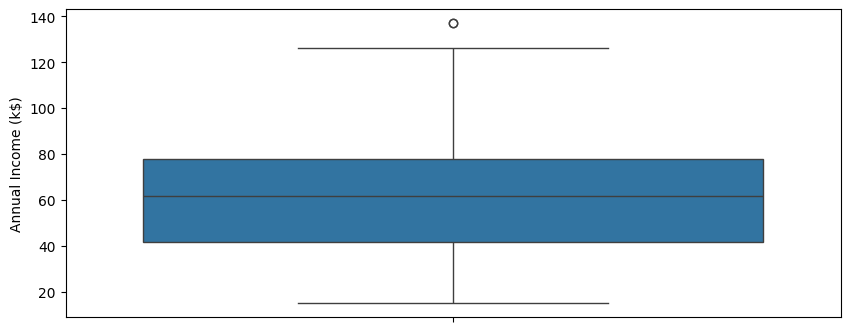

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(df['Annual Income (k$)'])

plt.show()

In [ ]:
df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [ ]:
X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

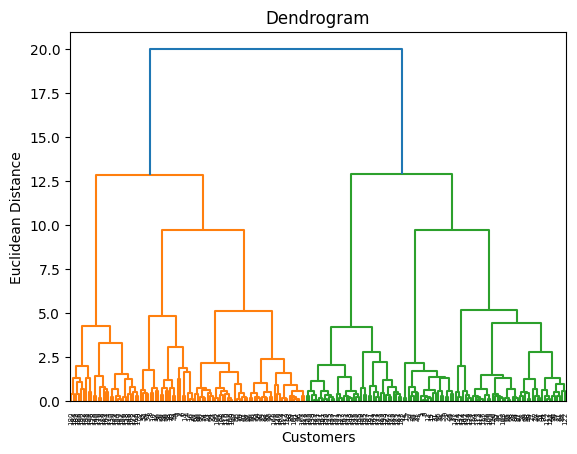

In [ ]:
linked = linkage(X_scaled, method='ward')

dendrogram(linked)

plt.title("Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Euclidean Distance")

plt.show()

In [ ]:
hc = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

In [ ]:
y_hc = hc.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = y_hc

In [ ]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,4
1,21,15,81,0
2,20,16,6,4
3,23,16,77,0
4,31,17,40,4


In [ ]:
cluster_profile = df.groupby('Cluster').mean()

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,26.560606,47.363636,56.787879
1,56.400000,55.288889,48.355556
2,32.692308,86.538462,82.128205
3,43.892857,91.285714,16.678571
4,44.318182,25.772727,20.272727


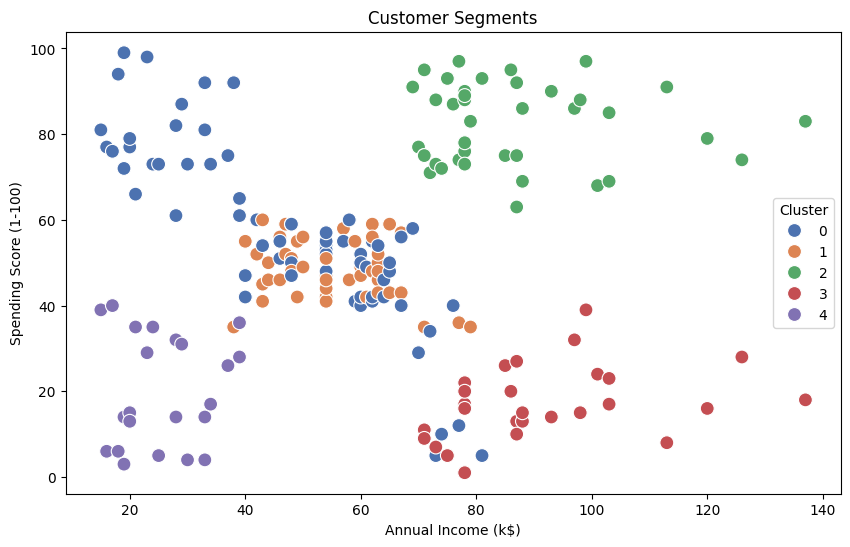

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='deep',
    s=100
)

plt.title("Customer Segments")

plt.show()

In [ ]:
score = silhouette_score(X_scaled, y_hc)

print("Silhouette Score:", score)

Silhouette Score: 0.39002826186267214


In [ ]:
pca = PCA()
x_pca = pca.fit_transform(X_scaled)

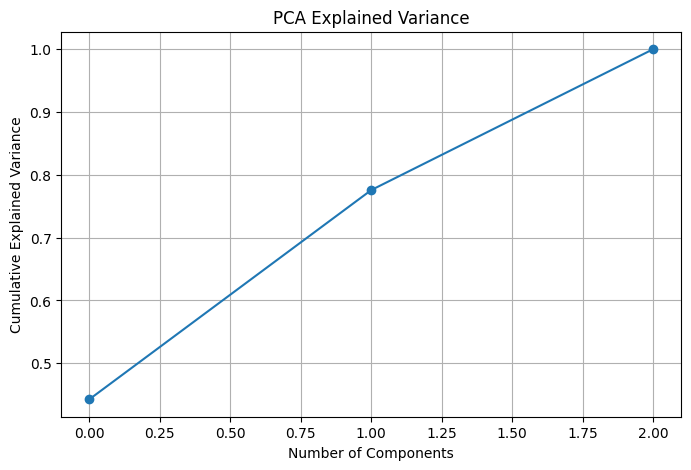

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

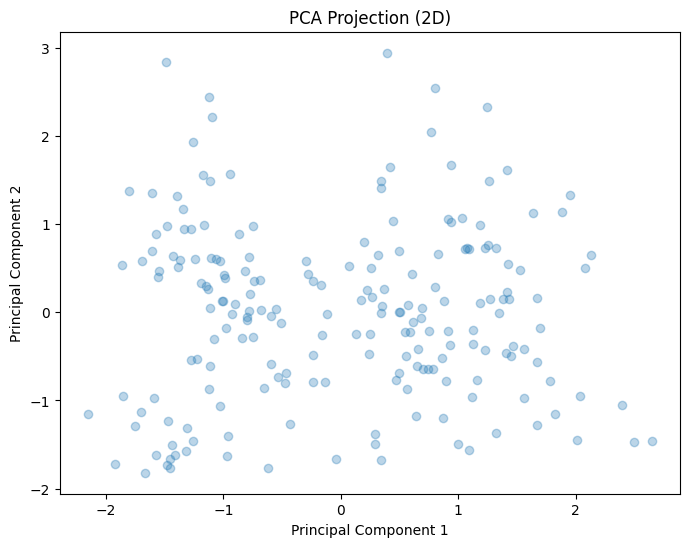

In [ ]:
pca_2 = PCA(n_components=2)

x_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(x_pca_2[:,0], x_pca_2[:,1], alpha=0.3)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Projection (2D)")

plt.show()

In [ ]:
# PCA Model
score_pca = silhouette_score(x_pca_2, y_hc)

print("Silhouette Score (PCA):", score_pca)

Silhouette Score (PCA): 0.31263485317148265
